# EIP-7904 — Ether transfer runtime analysis (`TX_BASE` & `VALUE_GAS`)
#### Maria Silva, May 2026

We analyse the runtime of `test_ether_transfers_onchain_receivers` on the 2026-05-18..22 EIP-7904 benchmark run. For each `(client, case_id)` combination we fit a NNLS model with `transfer_amount` as an extra feature and convert the coefficients to new gas values at a **100 Mgas/s** anchor:

- slope on `opcount` → `TX_BASE`
- `transfer_amount` coefficient → `VALUE_GAS`

In [1]:
import os
import sys
import re
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

In [2]:
sns.set_theme(
    style="whitegrid",
    palette="Set2",
    rc={"figure.dpi": 500, "axes.titlesize": 15},
)

current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
src_dir = os.path.join(repo_dir, "src")
sys.path.append(src_dir)

from data import extract_param_values
from nnls import fit_NNLS_without_low_diff_runs
from runtime_estimation import prepare_non_simple_model_data

ANCHOR_RATE = 100 * 1e6  # gas / s
TX_BASE = 21_000  # current per-tx base gas
VALUE_GAS_CURRENT = 9_000  # current extra gas for non-zero value transfer

DATA_CSV = os.path.join(
    repo_dir,
    "reports",
    "eip-7904",
    "runtime_estimation",
    "2026-05-22_2026-05-26",
    "gas_bench_data.csv",
)
TEST_NAME = "test_ether_transfers_onchain_receivers"

## 2. Load and prepare the data

Load the gas benchmark data, filter to the `test_ether_transfers_onchain_receivers` test, and extract the `transfer_amount` and `case_id` parameters from `test_params`.

`opcount` is the number of ether-transfer transactions packed into each block (~4750 at 100 Mgas). It is derived per case:

- `diff_to_contract` (Bittrex contracts, shared `codeHash` — clients can cache the code lookup) and `diff_to_unique_code_jumpdest_contract` (unique-code targets forcing a fresh code read + 24 KiB JUMPDEST analysis per tx): each tx executes exactly one `JUMP`, so `opcount = JUMP` opcode count from `trace_data.csv`.
- `diff_to_existent` and `diff_to_nonexistent` (transfers to EOAs): no opcodes in the trace, so `opcount = floor(block_gas_limit / TX_BASE)`.

This is a temporary "opcode trick" — once the benchmark harness emits a per-block transaction count into the trace directly, that field should be used instead.

In [3]:
TRACE_CSV = os.path.join(
    repo_dir,
    "reports",
    "eip-7904",
    "runtime_estimation",
    "2026-05-22_2026-05-26",
    "trace_data.csv",
)

gas_bench_df = pd.read_csv(DATA_CSV, low_memory=False)
trace_df = pd.read_csv(TRACE_CSV, low_memory=False, usecols=["test_title", "JUMP"])

df = gas_bench_df[gas_bench_df["test_name"] == TEST_NAME].copy()
df = df.dropna(axis=1, how="all")


def extract_case_id(test_params: str) -> str:
    return re.search(r"case_id_(.+)$", test_params).group(1)


df["transfer_amount"] = (
    df["test_params"]
    .apply(lambda s: extract_param_values(s, "transfer_amount"))
    .astype(int)
)
df["case_id"] = df["test_params"].apply(extract_case_id)

# Contract-target cases emit one JUMP per tx, so JUMP count is the tx count.
# EOA cases have no opcodes in the trace; fall back to floor(gas_limit / TX_BASE).
df = df.merge(trace_df, on="test_title", how="left")
floor_count = (df["block_limit_million"] * 1e6) // TX_BASE
df["opcount"] = df["JUMP"].where(df["JUMP"].notna(), floor_count).astype(float)
df = df.drop(columns=["JUMP"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14802 entries, 0 to 14801
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_name          14802 non-null  object 
 1   run_id               14802 non-null  object 
 2   ingestion_timestamp  14802 non-null  object 
 3   test_title           14802 non-null  object 
 4   run_duration_ms      14802 non-null  float64
 5   test_file            14802 non-null  object 
 6   test_name            14802 non-null  object 
 7   test_params          14802 non-null  object 
 8   block_limit_million  14802 non-null  int64  
 9   transfer_amount      14802 non-null  int64  
 10  case_id              14802 non-null  object 
 11  opcount              14802 non-null  float64
dtypes: float64(2), int64(2), object(8)
memory usage: 1.4+ MB


In [4]:
display(
    df[["transfer_amount", "case_id"]]
    .drop_duplicates()
    .sort_values(["case_id", "transfer_amount"])
    .reset_index(drop=True)
)

display(
    df.pivot_table(
        index=["case_id", "transfer_amount"],
        columns="client_name",
        values="run_duration_ms",
        aggfunc="count",
    )
)

,transfer_amount,case_id
0,0,diff_to_contract
1,1,diff_to_contract
2,0,diff_to_existent
3,1,diff_to_existent
4,0,diff_to_nonexistent
5,1,diff_to_nonexistent
6,0,diff_to_unique_code_jumpdest_contract
7,1,diff_to_unique_code_jumpdest_contract


client_name                                            besu  erigon   geth  \
case_id                               transfer_amount                        
diff_to_contract                      0                 4.0   220.0  638.0   
                                      1                 NaN   220.0  638.0   
diff_to_existent                      0                 4.0   220.0  638.0   
                                      1                 1.0   220.0  638.0   
diff_to_nonexistent                   0                 5.0   220.0  638.0   
                                      1                 NaN   220.0  638.0   
diff_to_unique_code_jumpdest_contract 0                 4.0   220.0  638.0   
                                      1                 NaN   220.0  638.0   

client_name                                            nethermind   reth  
case_id                               transfer_amount                     
diff_to_contract                      0                     429.0  561.0  
                                      1                     429.0  561.0  
diff_to_existent                      0                     429.0  561.0  
                                      1                     429.0  561.0  
diff_to_nonexistent                   0                     429.0  561.0  
                                      1                     429.0  561.0  
diff_to_unique_code_jumpdest_contract 0                     429.0  561.0  
                                      1                     429.0  561.0

## 3. Fit NNLS models per (client, case_id)

For each `(client_name, case_id)` group we drop the pre-computed `transfer_amount` column so the project helper `prepare_non_simple_model_data` re-extracts it from `test_params` and multiplies it by `opcount` (the standard convention). The design matrix becomes `[1, opcount, opcount × transfer_amount]`.

In [5]:
fitted = {}
results_records = []

for (client_name, case_id), group_df in df.groupby(["client_name", "case_id"]):
    fit_df = group_df.drop(columns=["transfer_amount"])
    try:
        model_df, features = prepare_non_simple_model_data(fit_df, ["transfer_amount"])
        result = fit_NNLS_without_low_diff_runs(model_df, features)
    except Exception as e:
        print(f"Skipping ({client_name}, {case_id}): {e}")
        continue

    fitted[(client_name, case_id)] = result
    record = {
        "client_name": client_name,
        "case_id": case_id,
        "nobs": result.nobs,
        "rsquared": result.rsquared,
        "rsquared_adj": result.rsquared_adj,
        "intercept": result.params["const"],
        "intercept_pvalue": result.pvalues["const"],
        "slope": result.params["opcount"],
        "slope_pvalue": result.pvalues["opcount"],
        "slope_conf_int_low": result.conf_int().loc["opcount", 0],
        "slope_conf_int_high": result.conf_int().loc["opcount", 1],
        "transfer_amount": result.params.get("transfer_amount", np.nan),
        "transfer_amount_pvalue": result.pvalues.get("transfer_amount", np.nan),
        "transfer_amount_conf_int_low": (
            result.conf_int().loc["transfer_amount", 0]
            if "transfer_amount" in result.params
            else np.nan
        ),
        "transfer_amount_conf_int_high": (
            result.conf_int().loc["transfer_amount", 1]
            if "transfer_amount" in result.params
            else np.nan
        ),
    }
    results_records.append(record)

results_df = (
    pd.DataFrame(results_records)
    .sort_values(["client_name", "case_id"])
    .reset_index(drop=True)
)
display(results_df.round(4))

,client_name,case_id,nobs,rsquared,rsquared_adj,intercept,intercept_pvalue,slope,slope_pvalue,slope_conf_int_low,slope_conf_int_high,transfer_amount,transfer_amount_pvalue,transfer_amount_conf_int_low,transfer_amount_conf_int_high
0,besu,diff_to_contract,4,0.0000,-0.5000,0.0000,1.0,2.2740,0.0,2.2209,2.3361,NaN,NaN,NaN,NaN
1,besu,diff_to_existent,5,0.9999,0.9999,0.0000,1.0,2.3001,0.0,2.2225,2.3668,7.5698,0.348,0.0000,7.6474
2,besu,diff_to_nonexistent,5,0.7007,0.6009,0.0000,1.0,7.1196,0.0,2.1385,9.0564,NaN,NaN,NaN,NaN
3,besu,diff_to_unique_code_jumpdest_contract,4,0.0000,-0.5000,0.0000,1.0,2.3369,0.0,2.2980,2.4019,NaN,NaN,NaN,NaN
4,erigon,diff_to_contract,440,0.9808,0.9807,4618.5095,0.0,0.1578,0.0,0.0961,0.2233,2.2442,0.000,2.2140,2.2758
5,erigon,diff_to_existent,440,0.9232,0.9228,531.5384,0.0,0.5085,0.0,0.4802,0.5338,0.3894,0.000,0.3731,0.4066
6,erigon,diff_to_nonexistent,440,0.9832,0.9831,2557.5323,0.0,0.3116,0.0,0.2653,0.3592,1.7623,0.000,1.7391,1.7860
7,erigon,diff_to_unique_code_jumpdest_contract,440,0.9206,0.9202,579.4560,0.0,0.5150,0.0,0.4885,0.5441,0.3836,0.000,0.3659,0.4020
8,geth,diff_to_contract,1276,0.9358,0.9357,231.2843,0.0,0.1045,0.0,0.1013,0.1077,0.0898,0.000,0.0879,0.0918
9,geth,diff_to_existent,1276,0.9197,0.9196,126.6964,0.0,0.0674,0.0,0.0652,0.0697,0.0580,0.000,0.0566,0.0595


In [6]:
for key, result in fitted.items():
    print(key)
    print(result.summary())

('besu', 'diff_to_contract')
                           NNLS Regression Results                            
Dep. Variable:          run_duration_ms              R-squared:          0.000
Model:                  NNLS                    Adj. R-squared:         -0.500
No. Observations:       4                                 RMSE:         297.73
Df Residuals:           2                                  MAE:         251.94
Df Model:               1      
                      coef     std err     P-value      [0.025      0.975]
------------------------------------------------------------------------------
         const      0.0000      0.0000       1.000      0.0000      0.0000
       opcount      2.2740      0.0314       0.000      2.2209      2.3361
Notes: Non-negative least squares with bootstrap inference (1000 iterations)
('besu', 'diff_to_existent')
                           NNLS Regression Results                            
Dep. Variable:          run_duration_ms              R-

## 4. Model fit analysis

We now inspect goodness-of-fit and the estimated coefficients across clients and cases to identify well-behaved models and any outlier configurations.

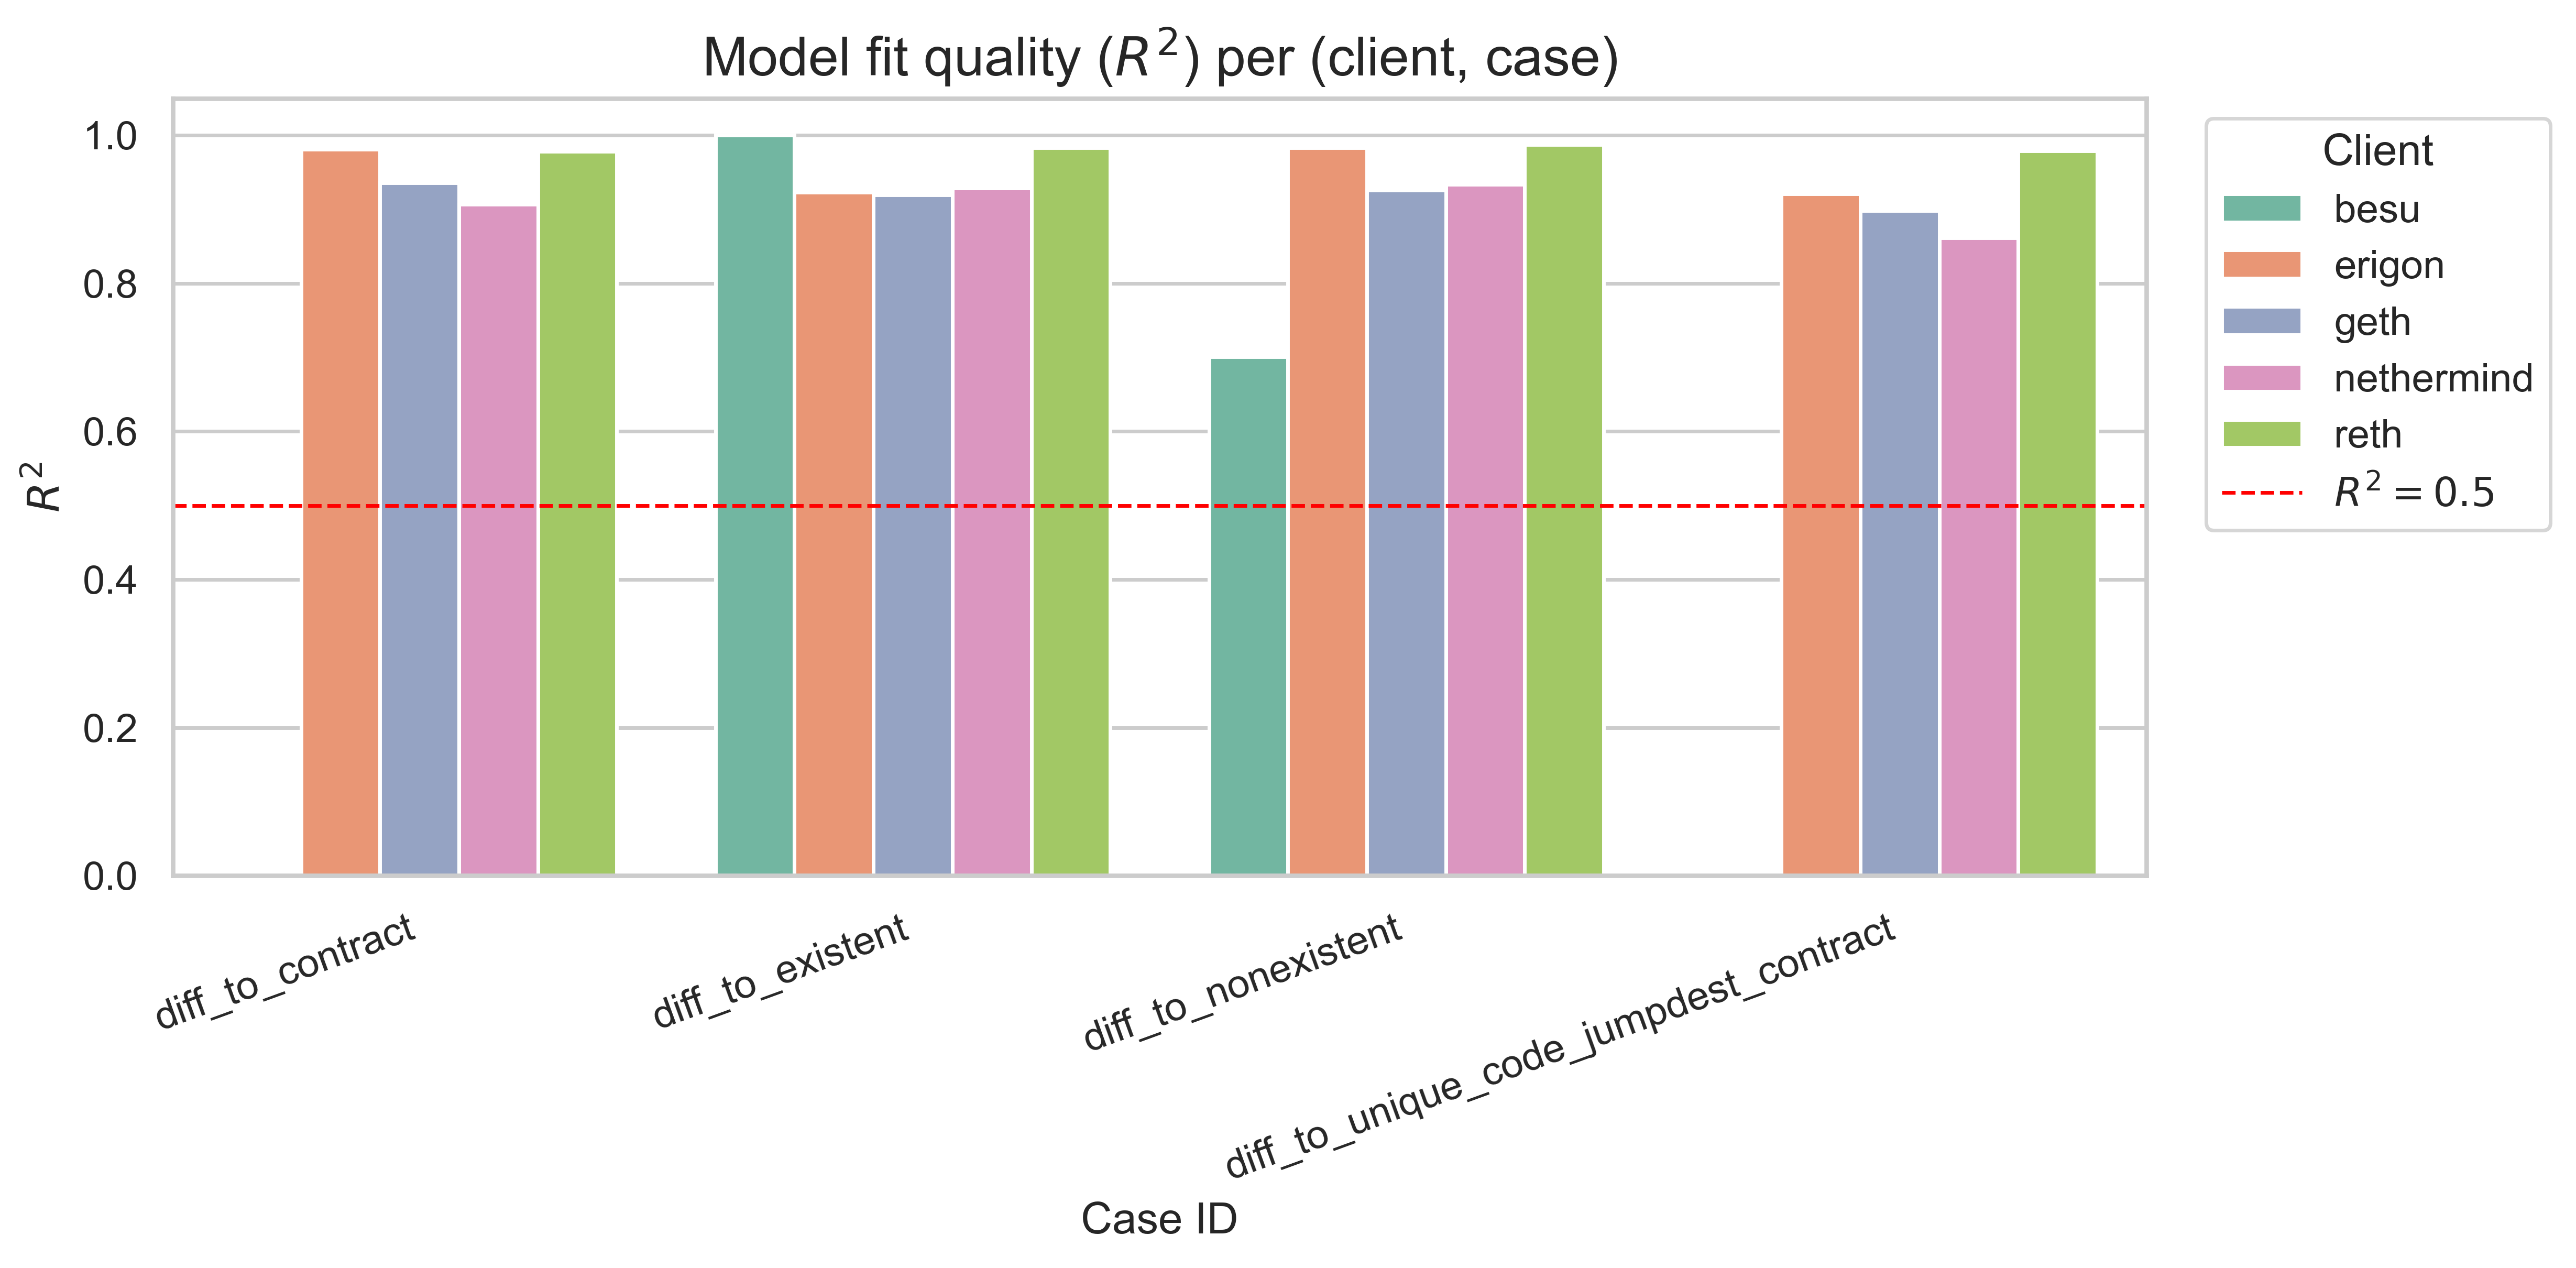

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="case_id",
    y="rsquared",
    hue="client_name",
    palette="Set2",
)
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label=r"$R^2 = 0.5$")
plt.title(r"Model fit quality ($R^2$) per (client, case)")
plt.xlabel("Case ID")
plt.ylabel(r"$R^2$")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Client", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

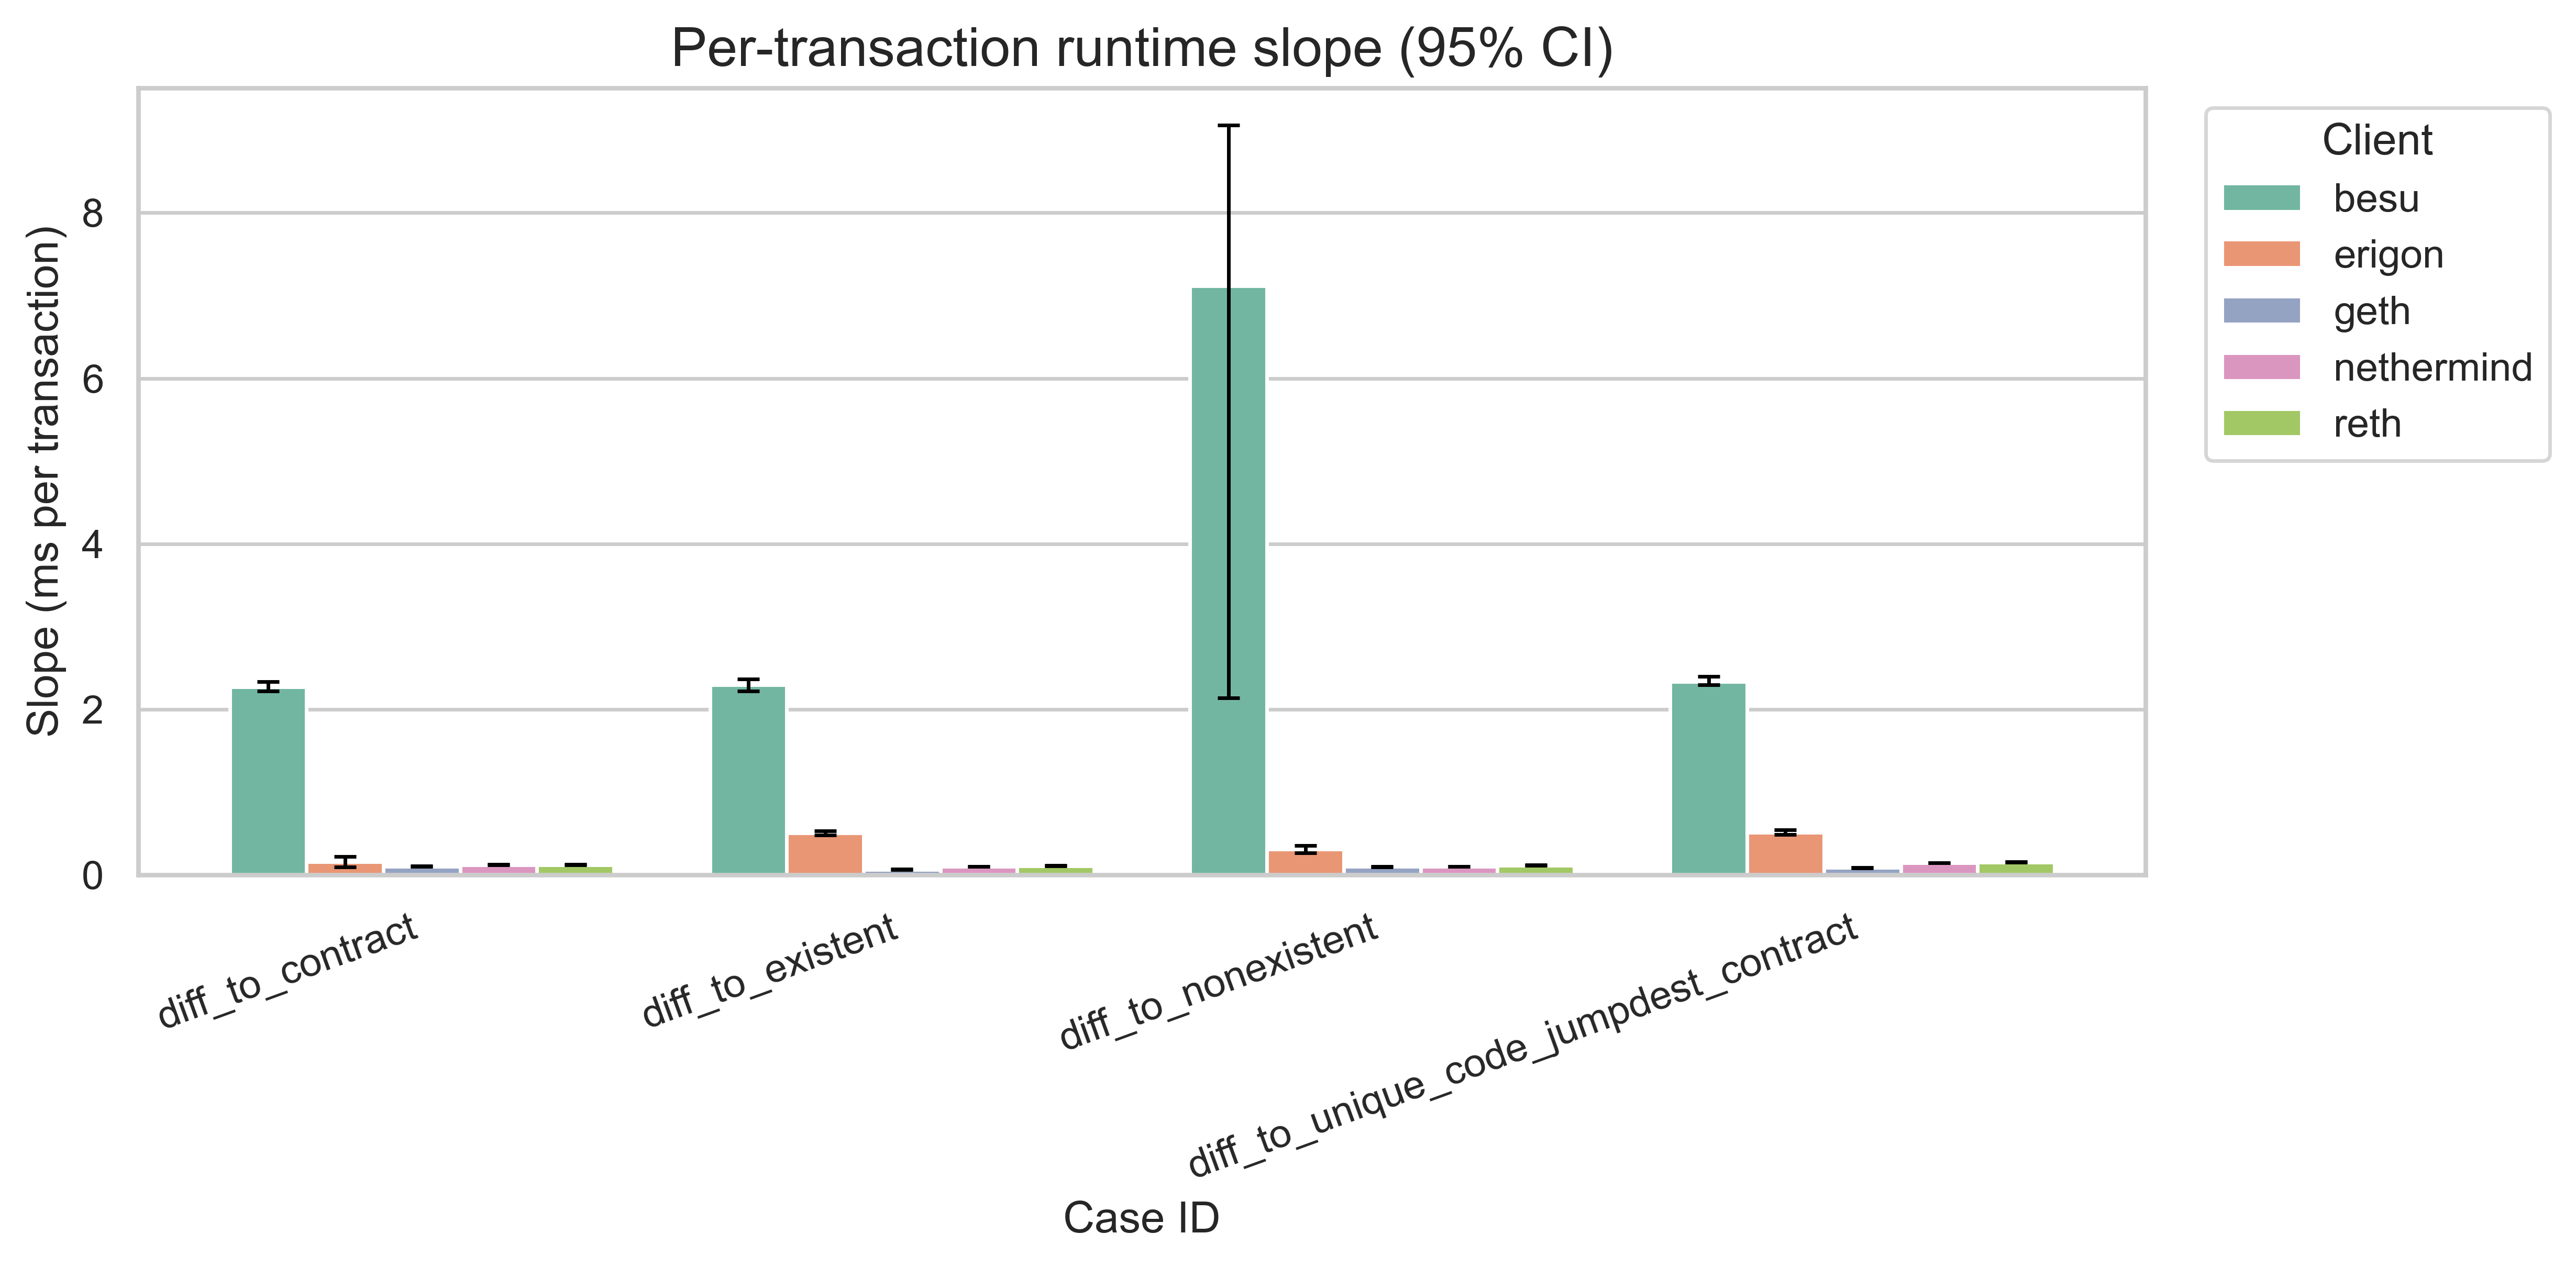

In [8]:
def _bar_with_errorbars(plot_df, value_col, low_col, high_col, ylabel, title):
    plot_df = plot_df.copy()
    plot_df["err_low"] = (plot_df[value_col] - plot_df[low_col]).clip(lower=0)
    plot_df["err_high"] = (plot_df[high_col] - plot_df[value_col]).clip(lower=0)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=plot_df,
        x="case_id",
        y=value_col,
        hue="client_name",
        palette="Set2",
        errorbar=None,
    )
    hue_order = [t.get_text() for t in ax.legend_.texts]
    case_order = [t.get_text() for t in ax.get_xticklabels()]
    for container, client in zip(ax.containers, hue_order):
        for bar, case_id in zip(container, case_order):
            row = plot_df[
                (plot_df["client_name"] == client) & (plot_df["case_id"] == case_id)
            ]
            if row.empty:
                continue
            x = bar.get_x() + bar.get_width() / 2
            ax.errorbar(
                x,
                row[value_col].values[0],
                yerr=[
                    [row["err_low"].values[0]],
                    [row["err_high"].values[0]],
                ],
                fmt="none",
                ecolor="black",
                capsize=3,
                linewidth=1,
            )
    plt.title(title)
    plt.xlabel("Case ID")
    plt.ylabel(ylabel)
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Client", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


_bar_with_errorbars(
    results_df,
    value_col="slope",
    low_col="slope_conf_int_low",
    high_col="slope_conf_int_high",
    ylabel="Slope (ms per transaction)",
    title="Per-transaction runtime slope (95% CI)",
)

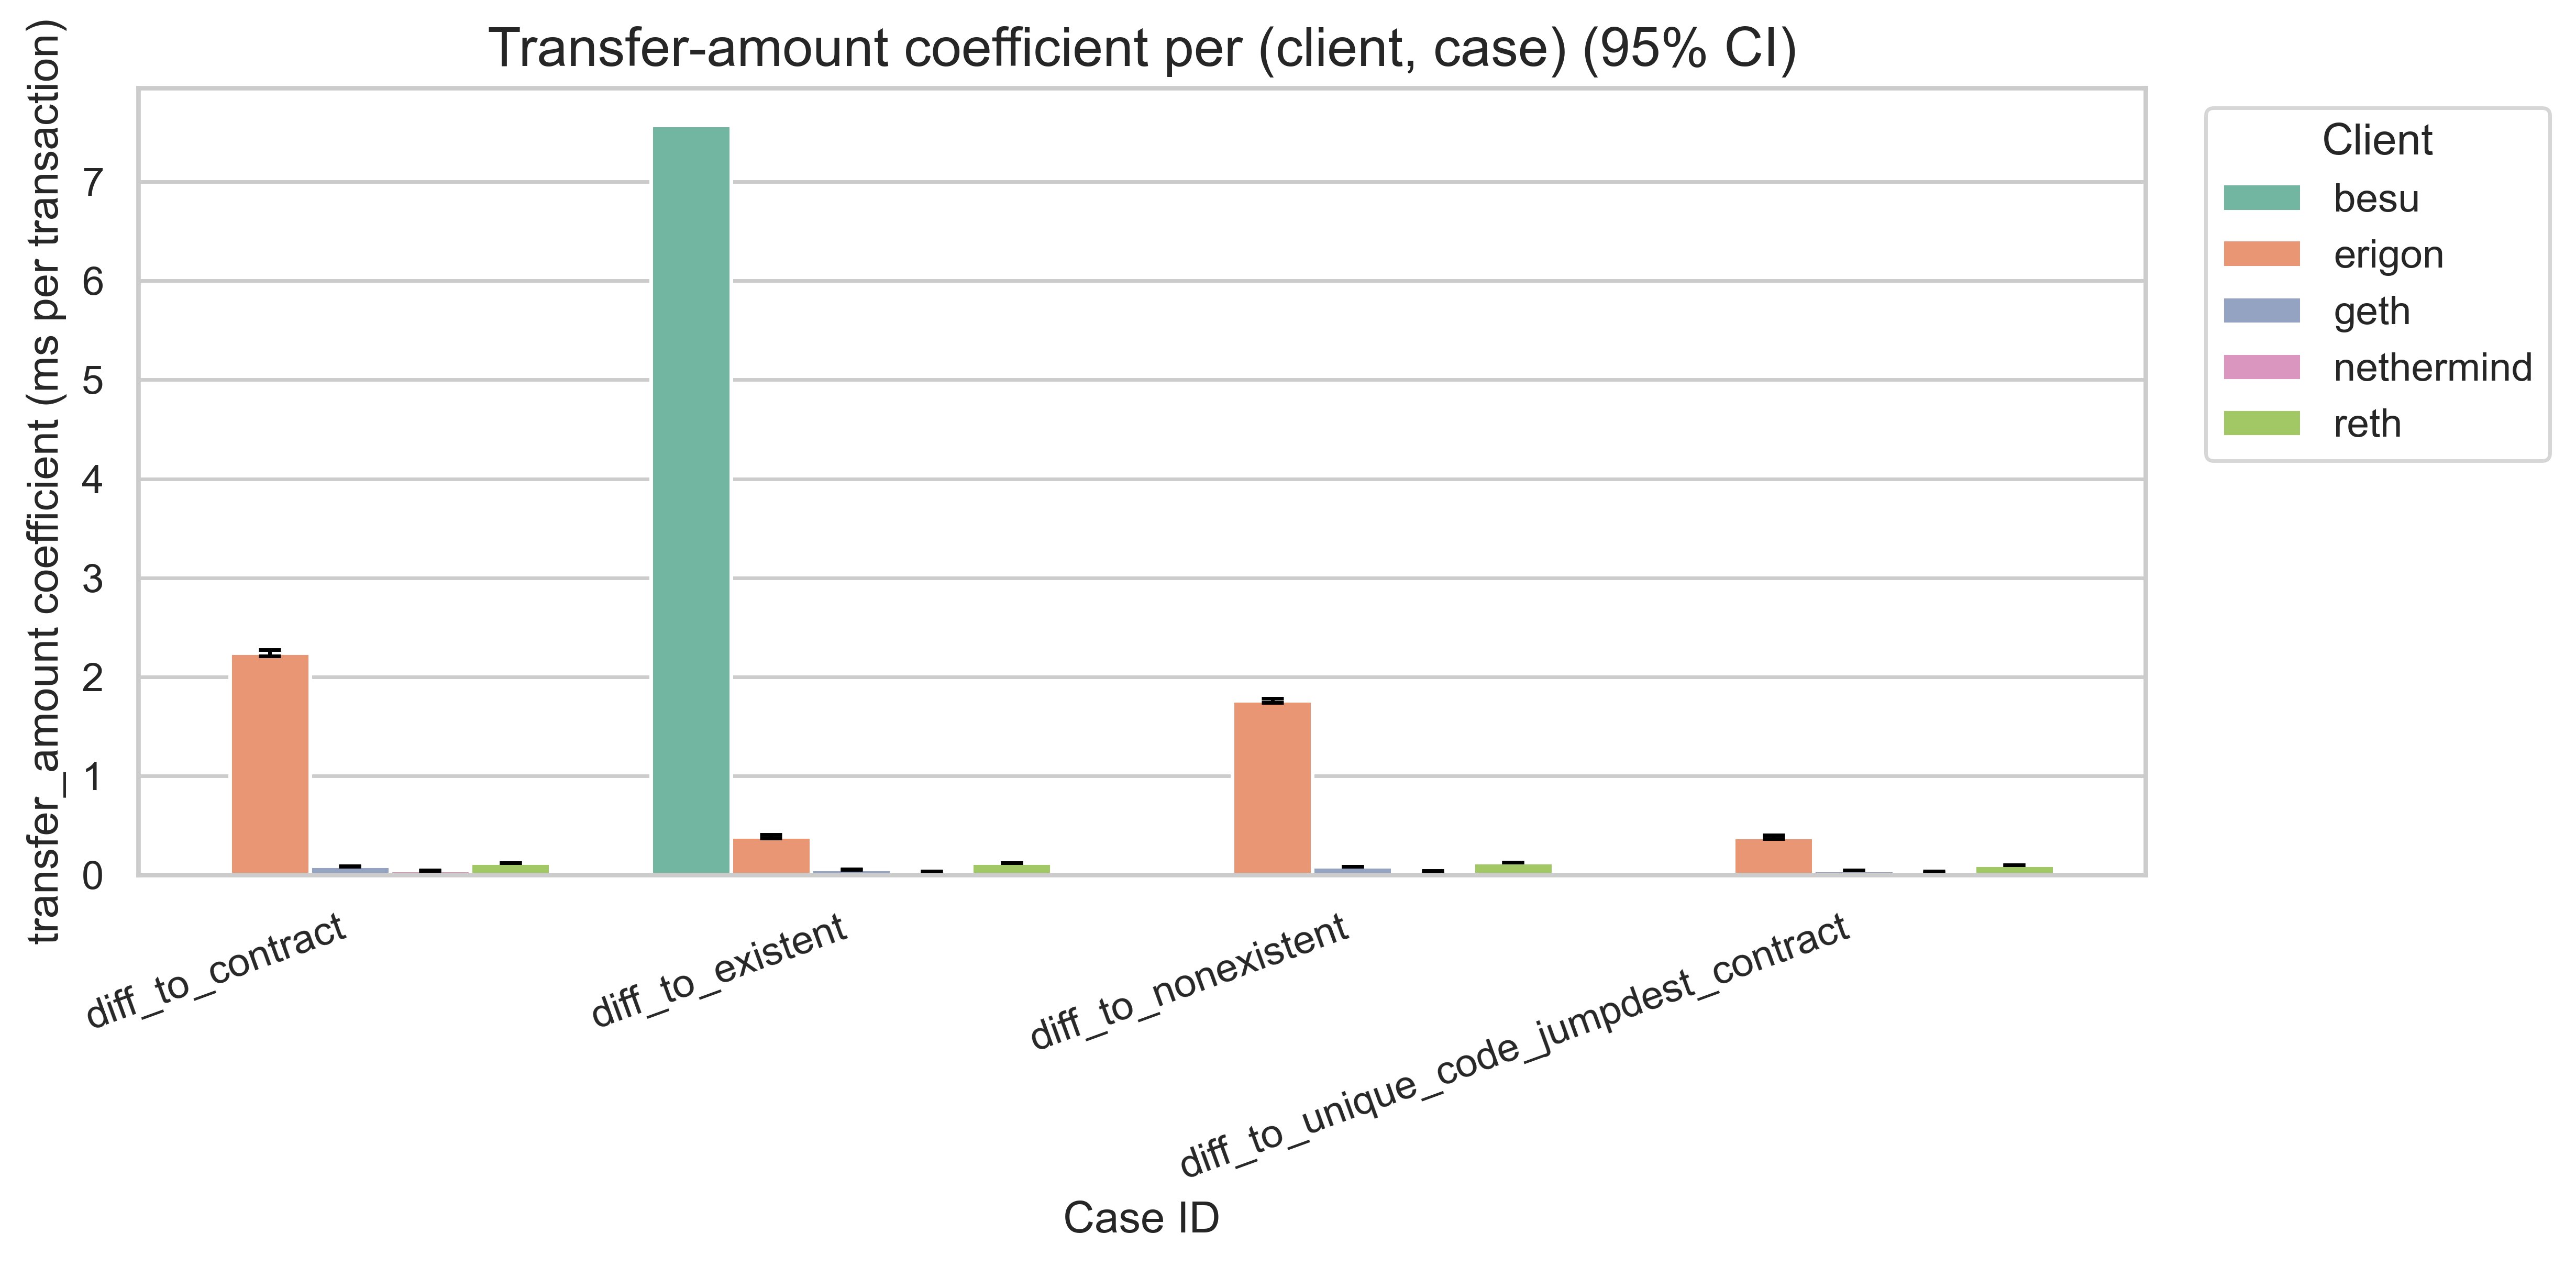

In [9]:
_bar_with_errorbars(
    results_df,
    value_col="transfer_amount",
    low_col="transfer_amount_conf_int_low",
    high_col="transfer_amount_conf_int_high",
    ylabel="transfer_amount coefficient (ms per transaction)",
    title="Transfer-amount coefficient per (client, case) (95% CI)",
)

In [10]:
fit_summary = results_df.assign(
    largest_slope=results_df["slope"]
    == results_df.groupby("client_name")["slope"].transform("max"),
    largest_transfer=results_df["transfer_amount"]
    == results_df.groupby("client_name")["transfer_amount"].transform("max"),
)
poor_fits = results_df[results_df["rsquared"] <= 0.5][
    ["client_name", "case_id", "rsquared"]
]
max_slope_row = results_df.loc[results_df["slope"].idxmax()]
max_transfer_row = results_df.loc[results_df["transfer_amount"].idxmax()]

print("Poor fits (R² <= 0.5):")
display(poor_fits if not poor_fits.empty else "None")
print(
    f"Largest slope: {max_slope_row['slope']:.6f} ms/tx "
    f"({max_slope_row['client_name']}, case={max_slope_row['case_id']})"
)
print(
    f"Largest transfer_amount coef: {max_transfer_row['transfer_amount']:.6f} ms/tx "
    f"({max_transfer_row['client_name']}, case={max_transfer_row['case_id']})"
)

Poor fits (R² <= 0.5):


,client_name,case_id,rsquared
0,besu,diff_to_contract,0.0
3,besu,diff_to_unique_code_jumpdest_contract,0.0


Largest slope: 7.119572 ms/tx (besu, case=diff_to_nonexistent)
Largest transfer_amount coef: 7.569809 ms/tx (besu, case=diff_to_existent)


## 5. Convert coefficients to new gas at the 100 Mgas/s anchor

Apply `new_gas = ANCHOR_RATE * runtime_ms / 1e3` (matching `src/proposal.py`) to map the `slope` coefficient to `TX_BASE` and the `transfer_amount` coefficient to `VALUE_GAS`. Conf-int low/high values are converted with `np.ceil`.

In [11]:
rename_map = {
    "slope": "TX_BASE",
    "transfer_amount": "VALUE_GAS",
}
current_gas_map = {
    "TX_BASE": TX_BASE,
    "VALUE_GAS": VALUE_GAS_CURRENT,
}

long_frames = []
for source_col, param_name in rename_map.items():
    sub = results_df[
        [
            "client_name",
            "case_id",
            source_col,
            f"{source_col}_conf_int_low",
            f"{source_col}_conf_int_high",
            f"{source_col}_pvalue",
            "rsquared",
        ]
    ].copy()
    sub = sub.rename(
        columns={
            source_col: "runtime_ms",
            f"{source_col}_conf_int_low": "conf_int_low",
            f"{source_col}_conf_int_high": "conf_int_high",
            f"{source_col}_pvalue": "pvalue",
        }
    )
    sub["param"] = param_name
    long_frames.append(sub)

new_gas_df = pd.concat(long_frames, ignore_index=True)

new_gas_df["new_gas"] = (ANCHOR_RATE * new_gas_df["runtime_ms"]) / 1e3
new_gas_df["new_gas_rounded"] = np.ceil(new_gas_df["new_gas"])
new_gas_df["new_gas_conf_int_low"] = np.ceil(
    (ANCHOR_RATE * new_gas_df["conf_int_low"]) / 1e3
)
new_gas_df["new_gas_conf_int_high"] = np.ceil(
    (ANCHOR_RATE * new_gas_df["conf_int_high"]) / 1e3
)
new_gas_df["current_gas"] = new_gas_df["param"].map(current_gas_map)
new_gas_df["change"] = (
    new_gas_df["new_gas_rounded"] / new_gas_df["current_gas"] - 1
).round(2)

new_gas_df = (
    new_gas_df[
        [
            "client_name",
            "case_id",
            "param",
            "runtime_ms",
            "conf_int_low",
            "conf_int_high",
            "pvalue",
            "rsquared",
            "new_gas",
            "new_gas_rounded",
            "new_gas_conf_int_low",
            "new_gas_conf_int_high",
            "current_gas",
            "change",
        ]
    ]
    .sort_values(["param", "client_name", "case_id"])
    .reset_index(drop=True)
)

display(new_gas_df.round(3))

,client_name,case_id,param,runtime_ms,conf_int_low,conf_int_high,pvalue,rsquared,new_gas,new_gas_rounded,new_gas_conf_int_low,new_gas_conf_int_high,current_gas,change
0,besu,diff_to_contract,TX_BASE,2.274,2.221,2.336,0.000,0.000,227398.162,227399.0,222095.0,233609.0,21000,9.83
1,besu,diff_to_existent,TX_BASE,2.300,2.223,2.367,0.000,1.000,230009.604,230010.0,222252.0,236681.0,21000,9.95
2,besu,diff_to_nonexistent,TX_BASE,7.120,2.139,9.056,0.000,0.701,711957.152,711958.0,213855.0,905642.0,21000,32.90
3,besu,diff_to_unique_code_jumpdest_contract,TX_BASE,2.337,2.298,2.402,0.000,0.000,233687.282,233688.0,229796.0,240191.0,21000,10.13
4,erigon,diff_to_contract,TX_BASE,0.158,0.096,0.223,0.000,0.981,15775.848,15776.0,9610.0,22329.0,21000,-0.25
5,erigon,diff_to_existent,TX_BASE,0.509,0.480,0.534,0.000,0.923,50854.915,50855.0,48020.0,53379.0,21000,1.42
6,erigon,diff_to_nonexistent,TX_BASE,0.312,0.265,0.359,0.000,0.983,31157.452,31158.0,26531.0,35920.0,21000,0.48
7,erigon,diff_to_unique_code_jumpdest_contract,TX_BASE,0.515,0.489,0.544,0.000,0.921,51497.110,51498.0,48855.0,54412.0,21000,1.45
8,geth,diff_to_contract,TX_BASE,0.105,0.101,0.108,0.000,0.936,10453.027,10454.0,10132.0,10773.0,21000,-0.50
9,geth,diff_to_existent,TX_BASE,0.067,0.065,0.070,0.000,0.920,6737.947,6738.0,6523.0,6969.0,21000,-0.68


## 6. Gas analysis & summary

With the per-client, per-case gas estimates in hand, we compare them against the current values (`TX_BASE = 21000`, `VALUE_GAS = 9000`) and identify the worst-case driver per parameter.

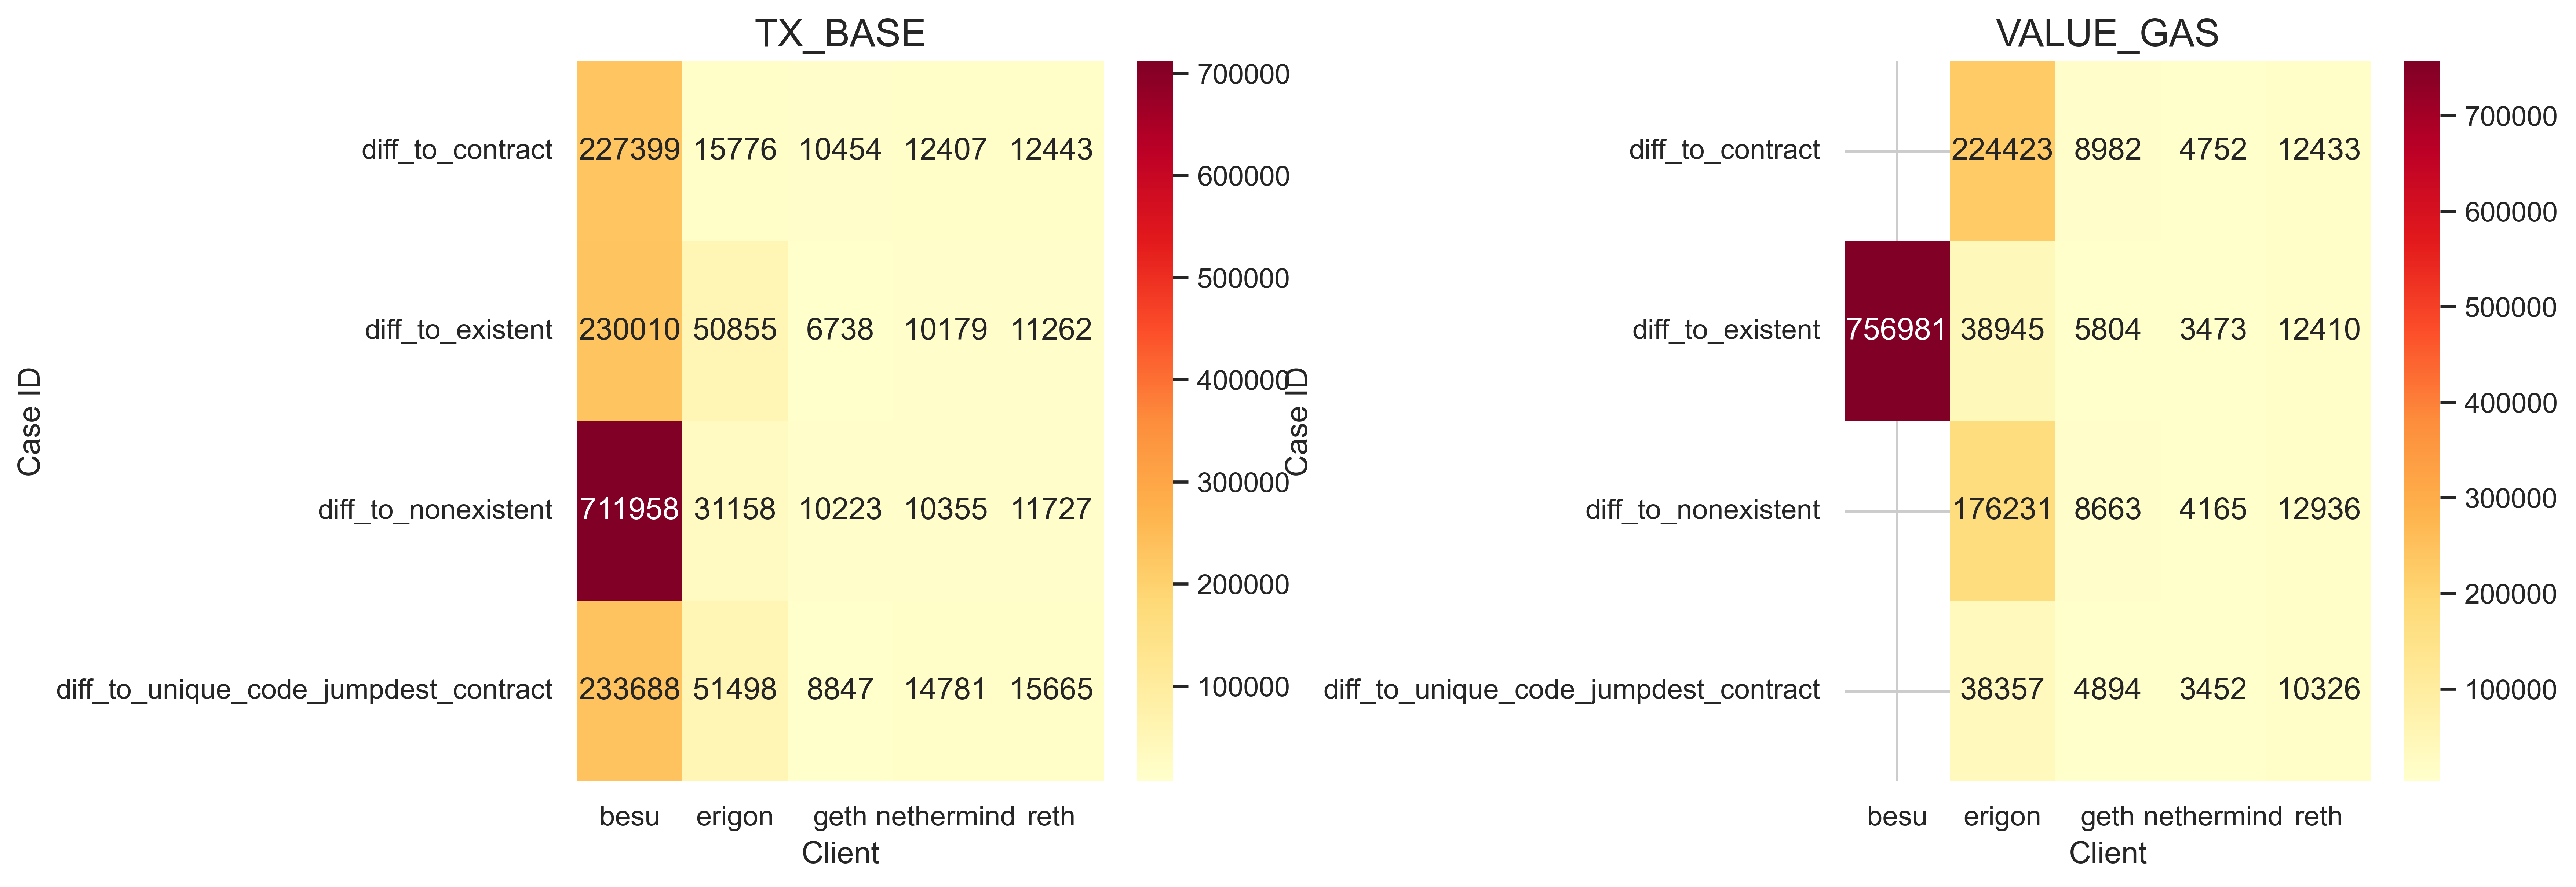

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, param in zip(axes, ["TX_BASE", "VALUE_GAS"]):
    pivot = new_gas_df[new_gas_df["param"] == param].pivot_table(
        index="case_id",
        columns="client_name",
        values="new_gas_rounded",
    )
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
    ax.set_title(param)
    ax.set_xlabel("Client")
    ax.set_ylabel("Case ID")
plt.tight_layout()
plt.show()

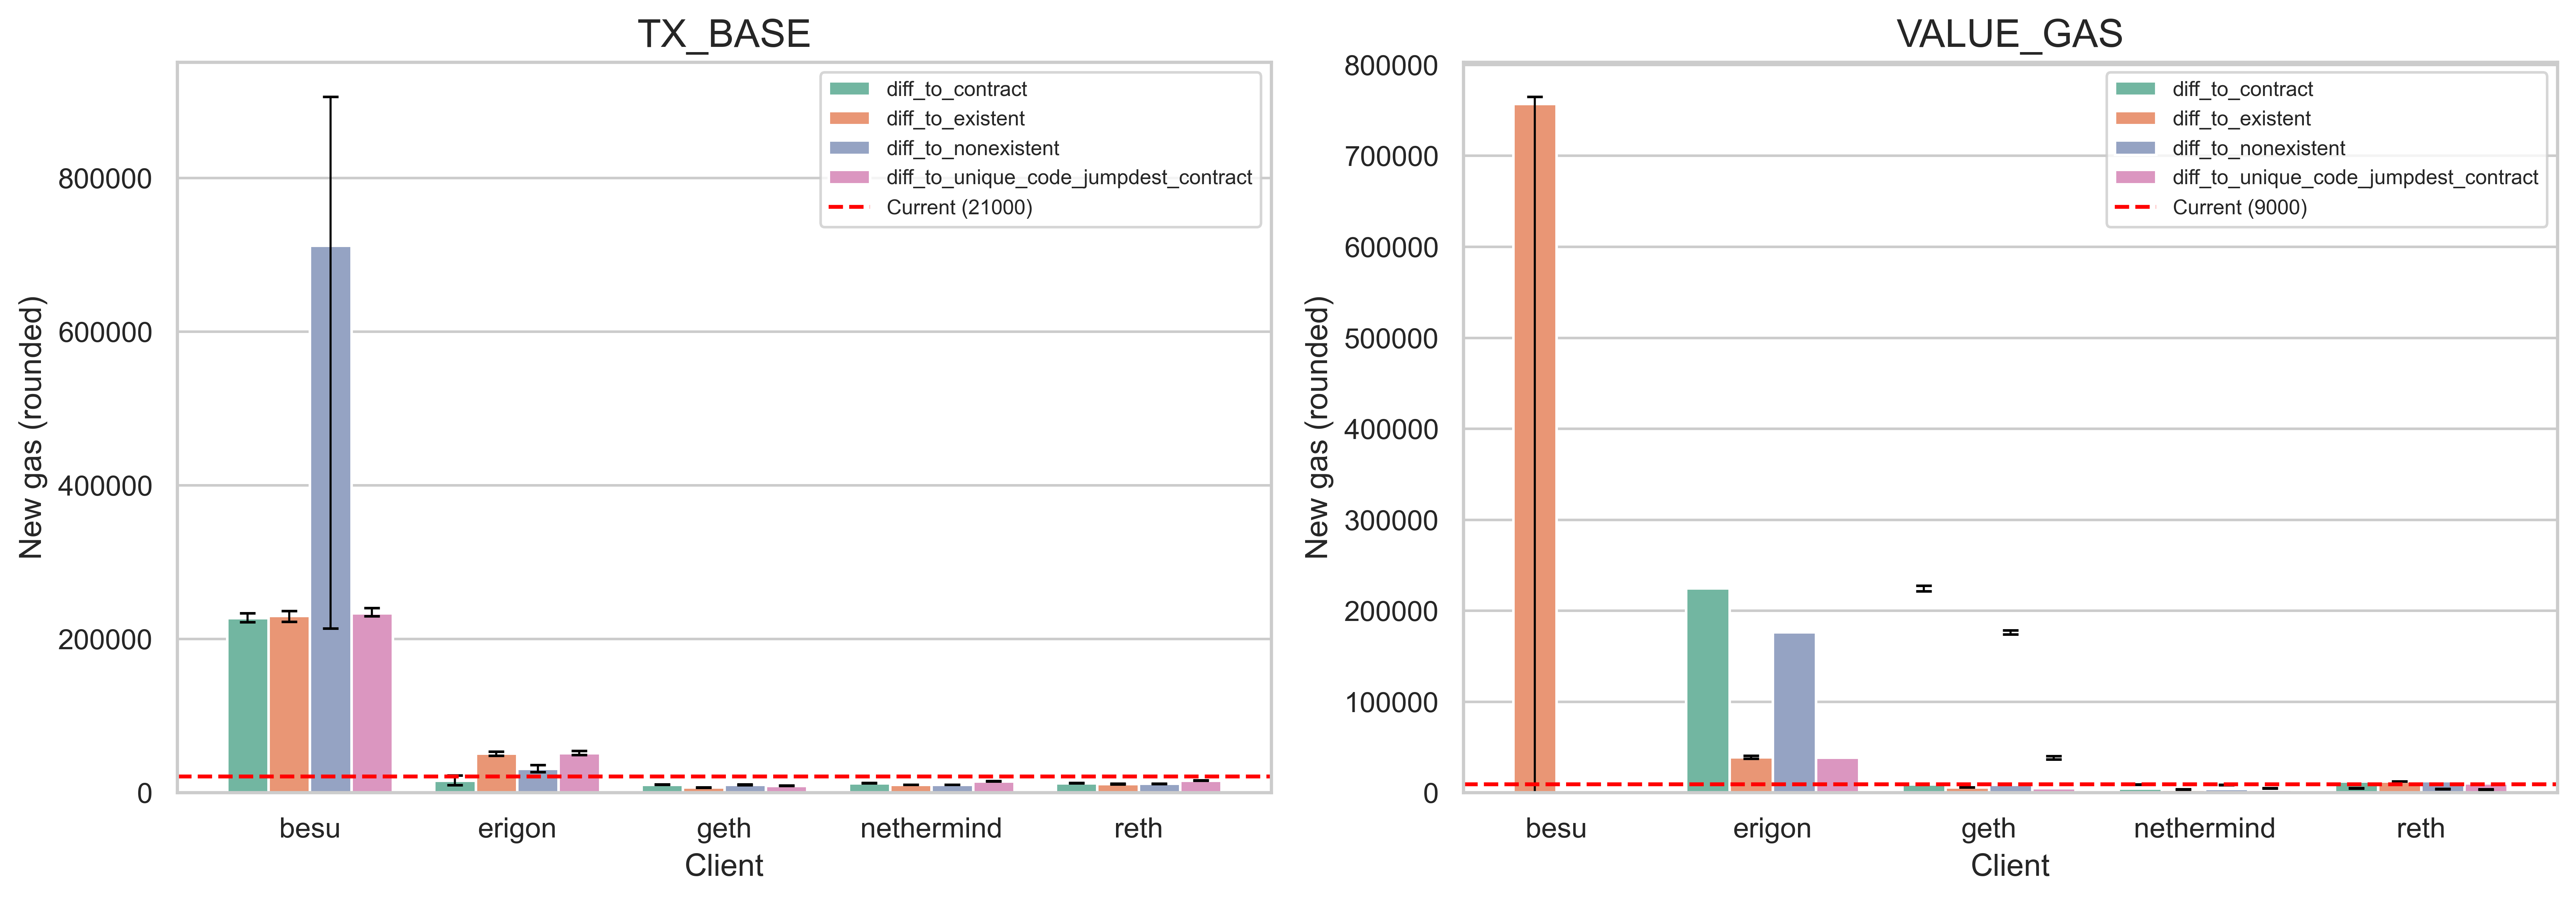

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, param in zip(axes, ["TX_BASE", "VALUE_GAS"]):
    sub = (
        new_gas_df[new_gas_df["param"] == param]
        .sort_values(["client_name", "case_id"])
        .reset_index(drop=True)
    )
    sns.barplot(
        data=sub,
        x="client_name",
        y="new_gas_rounded",
        hue="case_id",
        ax=ax,
        errorbar=None,
    )
    case_order = [t.get_text() for t in ax.legend_.texts]
    client_order = [t.get_text() for t in ax.get_xticklabels()]
    for container, case_id in zip(ax.containers, case_order):
        for bar, client in zip(container, client_order):
            row = sub[(sub["case_id"] == case_id) & (sub["client_name"] == client)]
            if row.empty:
                continue
            x = bar.get_x() + bar.get_width() / 2
            value = row["new_gas_rounded"].values[0]
            low = max(value - row["new_gas_conf_int_low"].values[0], 0)
            high = max(row["new_gas_conf_int_high"].values[0] - value, 0)
            ax.errorbar(
                x,
                value,
                yerr=[[low], [high]],
                fmt="none",
                ecolor="black",
                capsize=3,
                linewidth=0.8,
            )
    ax.axhline(
        current_gas_map[param],
        color="red",
        linestyle="--",
        label=f"Current ({current_gas_map[param]})",
    )
    ax.set_title(param)
    ax.set_xlabel("Client")
    ax.set_ylabel("New gas (rounded)")
    ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
idx_by_case = new_gas_df.groupby(["param", "case_id"])["new_gas_rounded"].idxmax()
worst_case_by_case_id = new_gas_df.loc[
    idx_by_case,
    [
        "param",
        "case_id",
        "client_name",
        "new_gas_rounded",
        "new_gas_conf_int_low",
        "new_gas_conf_int_high",
        "rsquared",
        "pvalue",
    ],
].reset_index(drop=True)

idx_overall = new_gas_df.groupby("param")["new_gas_rounded"].idxmax()
worst_case_overall = new_gas_df.loc[
    idx_overall,
    [
        "param",
        "client_name",
        "case_id",
        "new_gas_rounded",
        "new_gas_conf_int_low",
        "new_gas_conf_int_high",
        "rsquared",
        "pvalue",
        "current_gas",
        "change",
    ],
].reset_index(drop=True)

display(worst_case_by_case_id.round(3))
display(worst_case_overall.round(3))

,param,case_id,client_name,new_gas_rounded,new_gas_conf_int_low,new_gas_conf_int_high,rsquared,pvalue
0,TX_BASE,diff_to_contract,besu,227399.0,222095.0,233609.0,0.000,0.000
1,TX_BASE,diff_to_existent,besu,230010.0,222252.0,236681.0,1.000,0.000
2,TX_BASE,diff_to_nonexistent,besu,711958.0,213855.0,905642.0,0.701,0.000
3,TX_BASE,diff_to_unique_code_jumpdest_contract,besu,233688.0,229796.0,240191.0,0.000,0.000
4,VALUE_GAS,diff_to_contract,erigon,224423.0,221401.0,227577.0,0.981,0.000
5,VALUE_GAS,diff_to_existent,besu,756981.0,0.0,764740.0,1.000,0.348
6,VALUE_GAS,diff_to_nonexistent,erigon,176231.0,173914.0,178596.0,0.983,0.000
7,VALUE_GAS,diff_to_unique_code_jumpdest_contract,erigon,38357.0,36588.0,40204.0,0.921,0.000


,param,client_name,case_id,new_gas_rounded,new_gas_conf_int_low,new_gas_conf_int_high,rsquared,pvalue,current_gas,change
0,TX_BASE,besu,diff_to_nonexistent,711958.0,213855.0,905642.0,0.701,0.000,21000,32.90
1,VALUE_GAS,besu,diff_to_existent,756981.0,0.0,764740.0,1.000,0.348,9000,83.11


In [15]:
from IPython.display import Markdown, display

tx_row = worst_case_overall[worst_case_overall["param"] == "TX_BASE"].iloc[0]
vg_row = worst_case_overall[worst_case_overall["param"] == "VALUE_GAS"].iloc[0]

worst_tx_base = int(tx_row["new_gas_rounded"])
worst_value_gas = int(vg_row["new_gas_rounded"])

tx_change_pct = (worst_tx_base / TX_BASE - 1) * 100
vg_change_pct = (worst_value_gas / VALUE_GAS_CURRENT - 1) * 100

tx_direction = "higher" if tx_change_pct > 0 else "lower"
vg_direction = "higher" if vg_change_pct > 0 else "lower"

poor_fit_rows = new_gas_df[(new_gas_df["rsquared"] <= 0.5)]
worst_pairs = set(
    zip(
        worst_case_overall["param"],
        worst_case_overall["client_name"],
        worst_case_overall["case_id"],
    )
)
poor_in_worst = poor_fit_rows[
    poor_fit_rows.apply(
        lambda r: (r["param"], r["client_name"], r["case_id"]) in worst_pairs,
        axis=1,
    )
]

if len(poor_in_worst) > 0:
    caveats = "\n".join(
        f"  - `{r['param']}` driven by **{r['client_name']}** / case `{r['case_id']}` "
        f"has R\u00b2 = {r['rsquared']:.3f} (needs follow-up)."
        for _, r in poor_in_worst.iterrows()
    )
    caveats_block = f"**R\u00b2 caveats:**\n{caveats}"
else:
    caveats_block = (
        "**R\u00b2 caveats:** none — all worst-case drivers have R\u00b2 > 0.5."
    )

if tx_change_pct > 0 and vg_change_pct > 0:
    takeaway = (
        "Both `TX_BASE` and `VALUE_GAS` appear **under-priced** relative to the "
        "100 Mgas/s anchor."
    )
elif tx_change_pct < 0 and vg_change_pct < 0:
    takeaway = (
        "Both `TX_BASE` and `VALUE_GAS` appear **over-priced** relative to the "
        "100 Mgas/s anchor."
    )
else:
    tx_word = "under-priced" if tx_change_pct > 0 else "over-priced"
    vg_word = "under-priced" if vg_change_pct > 0 else "over-priced"
    takeaway = (
        f"`TX_BASE` appears **{tx_word}** while `VALUE_GAS` appears **{vg_word}** "
        "relative to the 100 Mgas/s anchor."
    )

summary = f"""### Summary

- **Worst-case `TX_BASE`:** {worst_tx_base} gas, driven by **{tx_row['client_name']}** on case `{tx_row['case_id']}` (R\u00b2 = {tx_row['rsquared']:.3f}, p-value = {tx_row['pvalue']:.3g}).
- **Worst-case `VALUE_GAS`:** {worst_value_gas} gas, driven by **{vg_row['client_name']}** on case `{vg_row['case_id']}` (R\u00b2 = {vg_row['rsquared']:.3f}, p-value = {vg_row['pvalue']:.3g}).
- **`TX_BASE`** is {tx_change_pct:+.1f}% vs. the current {TX_BASE} gas ({tx_direction}).
- **`VALUE_GAS`** is {vg_change_pct:+.1f}% vs. the current {VALUE_GAS_CURRENT} gas ({vg_direction}).

{caveats_block}

**Takeaway:** {takeaway}
"""

display(Markdown(summary))

### Summary

- **Worst-case `TX_BASE`:** 711958 gas, driven by **besu** on case `diff_to_nonexistent` (R² = 0.701, p-value = 0).
- **Worst-case `VALUE_GAS`:** 756981 gas, driven by **besu** on case `diff_to_existent` (R² = 1.000, p-value = 0.348).
- **`TX_BASE`** is +3290.3% vs. the current 21000 gas (higher).
- **`VALUE_GAS`** is +8310.9% vs. the current 9000 gas (higher).

**R² caveats:** none — all worst-case drivers have R² > 0.5.

**Takeaway:** Both `TX_BASE` and `VALUE_GAS` appear **under-priced** relative to the 100 Mgas/s anchor.
